In [285]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import seaborn as sns


## Data Preprocessing
First we read the csv file and inspect the data.

In [286]:
df = pd.read_csv("diabetes.csv")

In [287]:
# View the first 3 rows in the DataFrame 
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0,33.6,0.627,50,1
1,1,85,66,29.0,0,26.6,0.351,31,0
2,8,183,64,0.0,0,23.3,0.672,32,1


In [288]:
# View 5 random samples from the DataFrame
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
222,7,119,0,0.0,0,25.2,0.209,37,0
733,2,106,56,27.0,165,29.0,0.426,22,0
609,1,111,62,13.0,182,24.0,0.138,23,0
686,3,130,64,0.0,0,23.1,0.314,22,0
760,2,88,58,26.0,16,28.4,0.766,22,0


In [289]:
# General information about the DataFrame
print(f"Dataset has {df.shape[0]} samples. total columns of {df.shape[1]}"
      f" and {df.shape[1] - 1} features\n\n")
df.info()

Dataset has 768 samples. total columns of 9 and 8 features


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             762 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       763 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


In [290]:
# Statistics of the DataFrame
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,762.000000,768.000000,763.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.578740,79.799479,31.990695,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.937451,115.244002,7.905060,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [291]:
# Values counts for the results column
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [292]:
# Number of the duplicated rows
print(df.duplicated().sum())

0


In [293]:
# Number of Null values in each column
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               6
Insulin                     0
BMI                         5
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [294]:
# What percentage of the rows are missing values
df.isna().mean() * 100

Pregnancies                 0.000000
Glucose                     0.000000
BloodPressure               0.000000
SkinThickness               0.781250
Insulin                     0.000000
BMI                         0.651042
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

## Dealing With Missing Values
Now that we have inspected the data we se there exists null values in `SkinThickness` and `BMI` columns.
Two ways to deal with missing values are:
- Dropping the rows containing missing values.
- Imputation techniques:
    - Replacing the missing value with mean or median of the column for numerical data.
    - Replacing the missing value with mode of the column for categorical data.
    - Replacing the missing value with a constant.
    - KNNImputer uses the closest rows to fill out the missing value.

Here we use KNNImputer to fill out the missing values. We also add 2 extra columns to the dataset to know which columns had missing values before imputation.

In [295]:
df["SkinThickness_missing"] = df["SkinThickness"].isna().astype(int)
df["BMI_missing"] = df["BMI"].isna().astype(int)


# We move the outcome column to be the last column again
outcome = df["Outcome"]
df.drop(labels = "Outcome", axis = 1, inplace = True)
df["Outcome"] = outcome

df[(df["BMI_missing"] == 1) | (df["SkinThickness_missing"] == 1)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,SkinThickness_missing,BMI_missing,Outcome
8,2,197,70,NaN,543,30.5,0.158,53,1,0,1
52,5,88,66,NaN,23,24.4,0.342,30,1,0,0
67,2,109,92,NaN,0,42.7,0.845,54,1,0,0
87,2,100,68,NaN,71,38.5,0.324,26,1,0,0
100,1,163,72,NaN,0,39.0,1.222,33,1,0,1
101,1,151,60,NaN,0,26.1,0.179,22,1,0,0
127,1,118,58,36.0,94,NaN,0.261,23,0,1,0
149,2,90,70,17.0,0,NaN,0.085,22,0,1,0
175,8,179,72,42.0,130,NaN,0.719,36,0,1,1
192,7,159,66,0.0,0,NaN,0.383,36,0,1,1


In [296]:
imputer = KNNImputer(n_neighbors = 5)
df = pd.DataFrame(imputer.fit_transform(df), columns = df.columns)

## Dealing with Outliers
Since the SVM algorithm is sensitive to outliers we first visualize the data and the outliers using box plot and then remove the outliers with IQR.

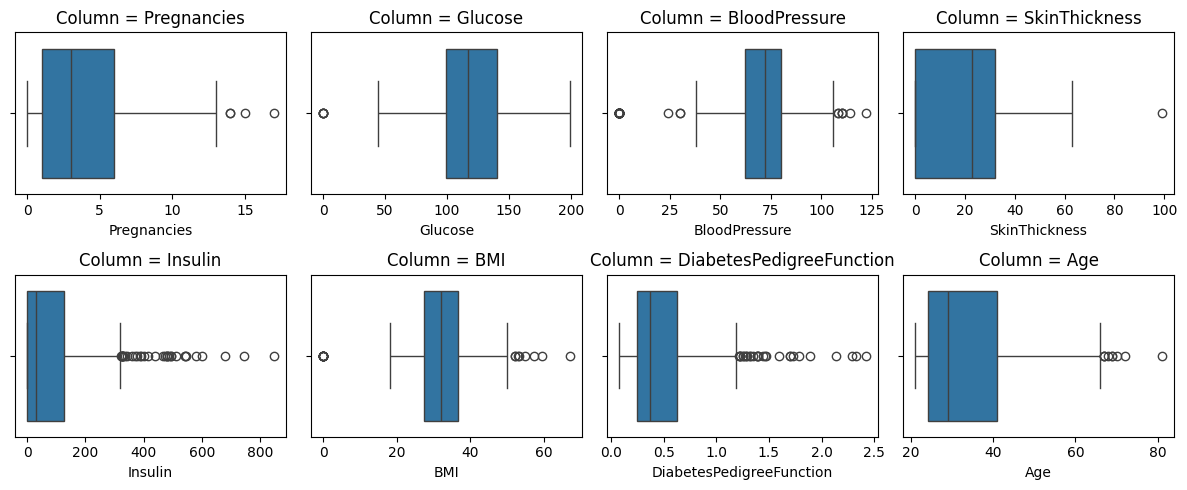

In [297]:
fig, axes = plt.subplots(2, 4, figsize = (12, 5))
axes = axes.flatten()

for i, name in enumerate(df.columns[:-3]):
    sns.boxplot(x = df[name], ax = axes[i])
    axes[i].set_title(f"Column = {name}")

plt.tight_layout()
plt.show()

In [298]:
# Do not include the columns for missing values and the outcome column
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
# Calculating the 25 and 75 percentiles and the INTER QUARTILE RANGE
Q1 = df[column_names].quantile(0.25)
Q3 = df[column_names].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Removing the outliers
within_bounds = (df[column_names] >= lower_bound) & (df[column_names] <= upper_bound)
df = df[within_bounds.all(axis = 1)]

df.shape



(639, 11)

In [299]:
# Only standardize the feature columns
scaler = StandardScaler()
df[column_names] = scaler.fit_transform(df[column_names])

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 10)

Now we train a SVM model with different kernels using the training and test data.

In [300]:
models = {
    "linear": svm.SVC(kernel = "linear"),
    "poly": svm.SVC(kernel = "poly"),
    "rbf": svm.SVC(kernel = "rbf"),
    "sigmoid": svm.SVC(kernel = "sigmoid")
}
# Train 3 different models with different kernels
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(f"Accuracy Score for {name} model = {accuracy_score(y_true = y_test, y_pred = predictions)}")

Accuracy Score for linear model = 0.8125
Accuracy Score for poly model = 0.7625
Accuracy Score for rbf model = 0.80625
Accuracy Score for sigmoid model = 0.75


Now we use Grid Search to find the best combination for two hyperparameters of SVM.

In [301]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 0.5, 1, 5, 10],
    "kernel": ["linear", "poly", "rbf", "sigmoid"]
}

svm_model = svm.SVC()

grid_search = GridSearchCV(estimator = svm_model, param_grid = param_grid, 
                           scoring = "accuracy", cv = 10, verbose = 1, n_jobs = -1)

grid_search.fit(X_train, y_train)
print(f"\nBest Hyperparameters: {grid_search.best_params_}\n\nBest Accuracy Score: {grid_search.best_score_}")

best_model = grid_search.best_estimator_
print(f"Test Accuracy Score: {accuracy_score(y_pred = best_model.predict(X_test), y_true = y_test)}")





Fitting 10 folds for each of 20 candidates, totalling 200 fits

Best Hyperparameters: {'C': 0.1, 'kernel': 'linear'}

Best Accuracy Score: 0.7764627659574469
Test Accuracy Score: 0.8125
